In [ ]:
!nvidia-smi

Sat Sep  5 12:22:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)
else:
    print("NO GPU DETECTED")

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
CUDA version: 12.8


GitHub repo clone

In [ ]:
%cd /content

!git clone https://github.com/jenishborah/smart-waste-segregation-ai

%cd /content/smart-waste-segregation-ai

/content
Cloning into 'smart-waste-segregation-ai'...
remote: Enumerating objects: 104, done.
remote: Counting objects: 100% (104/104), done.
remote: Compressing objects: 100% (78/78), done.
remote: Total 104 (delta 32), reused 35 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (104/104), 95.56 KiB | 7.35 MiB/s, done.
Resolving deltas: 100% (32/32), done.
/content/smart-waste-segregation-ai


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path

ROOT = Path("/content/smart-waste-segregation-ai")

DRIVE_DATASET = Path(
    "/content/drive/MyDrive/ENCRYPTOS_TEZHACK/Dataset"
)

ZIP_PATH = DRIVE_DATASET / "raw.zip"
DRIVE_REPORTS = DRIVE_DATASET / "reports"

RAW_DIR = ROOT / "data" / "raw"
REPORTS_DIR = ROOT / "data" / "reports"

print("Repository:", ROOT)
print("ZIP exists:", ZIP_PATH.exists())
print("Drive reports exists:", DRIVE_REPORTS.exists())
print("Repository raw:", RAW_DIR)

Repository: /content/smart-waste-segregation-ai
ZIP exists: True
Drive reports exists: True
Repository raw: /content/smart-waste-segregation-ai/data/raw


In [ ]:
!mkdir -p "/content/smart-waste-segregation-ai/data/reports"

!cp -r "/content/drive/MyDrive/ENCRYPTOS_TEZHACK/Dataset/reports/." \
      "/content/smart-waste-segregation-ai/data/reports/"

In [ ]:
!ls -lh "/content/smart-waste-segregation-ai/data/reports" | head -30

total 4.1M
-rw------- 1 root root 1.1K Sep  5 12:32 class_distribution.csv
-rw------- 1 root root 4.6K Sep  5 12:32 conflict_decisions_completed.csv
-rw------- 1 root root 1.2K Sep  5 12:32 conflict_decisions.csv
-rw------- 1 root root 1.5M Sep  5 12:32 conflict_review.zip
-rw------- 1 root root   37 Sep  5 12:32 corrupt_images.csv
-rw------- 1 root root   51 Sep  5 12:32 cross_dataset_duplicates.csv
-rw------- 1 root root  186 Sep  5 12:32 dataset_summary.csv
-rw------- 1 root root 1.9M Sep  5 12:32 dataset_v1_curated_manifest.csv
-rw------- 1 root root 4.7K Sep  5 12:32 dataset_v1_curation_audit.csv
-rw------- 1 root root 663K Sep  5 12:32 dataset_v1_duplicate_groups.csv


In [ ]:
import pandas as pd

df = pd.read_csv(manifest)

print("Shape:", df.shape)

print("\nSplits:")
print(df["split"].value_counts())

print("\nClasses:", df["unified_class"].nunique())

print("\nClasses:")
print(df["unified_class"].value_counts())

Shape: (13196, 16)

Splits:
split
train    9237
val      1980
test     1979
Name: count, dtype: int64

Classes: 16

Classes:
unified_class
Electronic Device             1500
Plastic                       1403
Residual                      1277
Metal                         1200
Paper                         1094
Hazardous Waste                939
Glass                          921
Large Electronic Appliance     900
Cardboard                      864
Organic Stream                 674
Recyclable Stream              659
Vegetation                     436
Food Organics                  411
Textile                        318
Battery                        300
Electronic Component           300
Name: count, dtype: int64


In [ ]:
import zipfile
from pathlib import Path

ZIP_PATH = Path(
    "/content/drive/MyDrive/ENCRYPTOS_TEZHACK/Dataset/raw.zip"
)

RAW_DIR = Path(
    "/content/smart-waste-segregation-ai/data/raw"
)

RAW_DIR.mkdir(parents=True, exist_ok=True)

print("ZIP:", ZIP_PATH)
print("Destination:", RAW_DIR)

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    members = z.namelist()

print("ZIP entries:", len(members))
print("First 20 entries:")

for m in members[:20]:
    print(m)

ZIP: /content/drive/MyDrive/ENCRYPTOS_TEZHACK/Dataset/raw.zip
Destination: /content/smart-waste-segregation-ai/data/raw
ZIP entries: 13304
First 20 entries:
raw/
raw/ewaste/
raw/ewaste/test/
raw/ewaste/test/Battery/
raw/ewaste/test/Battery/battery_106.jpg
raw/ewaste/test/Battery/battery_128.jpg
raw/ewaste/test/Battery/battery_148.jpg
raw/ewaste/test/Battery/battery_152.jpg
raw/ewaste/test/Battery/battery_174.jpg
raw/ewaste/test/Battery/battery_177.jpg
raw/ewaste/test/Battery/battery_190.jpg
raw/ewaste/test/Battery/battery_192.jpg
raw/ewaste/test/Battery/battery_211.jpg
raw/ewaste/test/Battery/battery_22.jpg
raw/ewaste/test/Battery/battery_24.jpg
raw/ewaste/test/Battery/battery_241.jpg
raw/ewaste/test/Battery/battery_242.jpg
raw/ewaste/test/Battery/battery_251.jpg
raw/ewaste/test/Battery/battery_259.jpg
raw/ewaste/test/Battery/battery_260.jpg


In [ ]:
import zipfile
from pathlib import Path
import shutil

ZIP_PATH = Path(
    "/content/drive/MyDrive/ENCRYPTOS_TEZHACK/Dataset/raw.zip"
)

RAW_DIR = Path(
    "/content/smart-waste-segregation-ai/data/raw"
)

RAW_DIR.mkdir(parents=True, exist_ok=True)

print("Extracting dataset...")
print("From:", ZIP_PATH)
print("To:", RAW_DIR)

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    members = z.namelist()

    for i, member in enumerate(members):
        # Remove the leading "raw/" from every ZIP path
        if not member.startswith("raw/"):
            continue

        relative = member[4:]

        # Skip the raw/ directory itself
        if not relative:
            continue

        destination = RAW_DIR / relative

        if member.endswith("/"):
            destination.mkdir(parents=True, exist_ok=True)
        else:
            destination.parent.mkdir(parents=True, exist_ok=True)

            with z.open(member) as source, open(destination, "wb") as target:
                shutil.copyfileobj(source, target)

        if (i + 1) % 1000 == 0:
            print(f"Processed ZIP entries: {i + 1}/{len(members)}")

print("\nExtraction complete.")

Extracting dataset...
From: /content/drive/MyDrive/ENCRYPTOS_TEZHACK/Dataset/raw.zip
To: /content/smart-waste-segregation-ai/data/raw
Processed ZIP entries: 1000/13304
Processed ZIP entries: 2000/13304
Processed ZIP entries: 3000/13304
Processed ZIP entries: 4000/13304
Processed ZIP entries: 5000/13304
Processed ZIP entries: 6000/13304
Processed ZIP entries: 7000/13304
Processed ZIP entries: 8000/13304
Processed ZIP entries: 9000/13304
Processed ZIP entries: 10000/13304
Processed ZIP entries: 11000/13304
Processed ZIP entries: 12000/13304
Processed ZIP entries: 13000/13304

Extraction complete.


In [ ]:
from pathlib import Path

RAW_DIR = Path(
    "/content/smart-waste-segregation-ai/data/raw"
)

print("RAW directory exists:", RAW_DIR.exists())

print("\nTop-level contents:")

for p in sorted(RAW_DIR.iterdir()):
    print(" -", p.name)

RAW directory exists: True

Top-level contents:
 - README.md
 - ewaste
 - phenomsg
 - realwaste
 - trashnet


In [ ]:
from pathlib import Path

RAW_DIR = Path("/content/smart-waste-segregation-ai/data/raw")

extensions = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

images = [
    p for p in RAW_DIR.rglob("*")
    if p.is_file() and p.suffix.lower() in extensions
]

print("Extracted image files:", len(images))

Extracted image files: 13196


In [ ]:
import pandas as pd
from pathlib import Path

ROOT = Path("/content/smart-waste-segregation-ai")
RAW_DIR = ROOT / "data/raw"
MANIFEST = ROOT / "data/reports/dataset_v1_curated_manifest.csv"

df = pd.read_csv(MANIFEST)

missing = []

for image_path in df["image_path"]:
    if not (RAW_DIR / image_path).exists():
        missing.append(image_path)

print("Manifest images:", len(df))
print("Found:", len(df) - len(missing))
print("Missing:", len(missing))

if missing:
    print("\nFirst missing files:")
    for p in missing[:20]:
        print(p)
else:
    print("\nALL 13,196 MANIFEST IMAGES FOUND.")

Manifest images: 13196
Found: 13196
Missing: 0

ALL 13,196 MANIFEST IMAGES FOUND.


In [ ]:
for split in ["train", "val", "test"]:
    subset = df[df["split"] == split]

    found = sum(
        (RAW_DIR / p).exists()
        for p in subset["image_path"]
    )

    print(f"{split:5s}: {found}/{len(subset)} images found")

train: 9237/9237 images found
val  : 1980/1980 images found
test : 1979/1979 images found


In [ ]:
import json
from pathlib import Path

ROOT = Path("/content/smart-waste-segregation-ai")
CONFIG = ROOT / "configs/training_config.json"

print("Config exists:", CONFIG.exists())

with open(CONFIG, "r") as f:
    config = json.load(f)

print(json.dumps(config, indent=2))

Config exists: True
{
  "architecture": "resnet18",
  "image_size": 224,
  "batch_size": 32,
  "epochs": 20,
  "learning_rate": 0.0001,
  "weight_decay": 0.0001,
  "patience": 5,
  "seed": 42,
  "num_workers": 2,
  "num_classes": 16,
  "dataset": {
    "manifest": "reports/dataset_v1_curated_manifest.csv",
    "raw_directory": "raw"
  },
  "splits": {
    "train": "train",
    "validation": "val",
    "test": "test"
  },
  "output": {
    "directory": "training_outputs",
    "best_model": "best_model.pth",
    "class_names": "class_names.json",
    "class_to_idx": "class_to_idx.json",
    "history": "training_history.csv",
    "metadata": "training_metadata.json",
    "classification_report": "classification_report.csv",
    "confusion_matrix": "confusion_matrix.csv",
    "test_results": "test_results.json"
  }
}


In [ ]:
%cd /content/smart-waste-segregation-ai

!python -m py_compile ml/train.py

print("train.py compilation: OK")

/content/smart-waste-segregation-ai
train.py compilation: OK


In [ ]:
!python ml/train.py


WASTE SEGREGATION AI
MODEL TRAINING

Project root:
/content/smart-waste-segregation-ai

Manifest:
/content/smart-waste-segregation-ai/data/reports/dataset_v1_curated_manifest.csv

Raw directory:
/content/smart-waste-segregation-ai/data/raw

Architecture:
resnet18

Device:
cuda
GPU: Tesla T4
CUDA: 12.8
GPU memory: 14.56 GB

CLASSES
 0  Battery                          300
 1  Cardboard                        864
 2  Electronic Component             300
 3  Electronic Device               1500
 4  Food Organics                    411
 5  Glass                            921
 6  Hazardous Waste                  939
 7  Large Electronic Appliance       900
 8  Metal                           1200
 9  Organic Stream                   674
10  Paper                           1094
11  Plastic                         1403
12  Recyclable Stream                659
13  Residual                        1277
14  Textile                          318
15  Vegetation                       436

VERIFYING

In [ ]:
import pandas as pd

report = pd.read_csv(
    "/content/smart-waste-segregation-ai/training_outputs/classification_report.csv"
)

cm = pd.read_csv(
    "/content/smart-waste-segregation-ai/training_outputs/confusion_matrix.csv"
)

print("=== CLASSIFICATION REPORT ===")
display(report)

print("\n=== CONFUSION MATRIX ===")
display(cm)

=== CLASSIFICATION REPORT ===


,Unnamed: 0,precision,recall,f1-score,support
0,Battery,0.596491,0.755556,0.666667,45.000000
1,Cardboard,0.743750,0.894737,0.812287,133.000000
2,Electronic Component,0.725000,0.783784,0.753247,37.000000
3,Electronic Device,0.818898,0.873950,0.845528,238.000000
4,Food Organics,0.850746,0.838235,0.844444,68.000000
5,Glass,0.804196,0.815603,0.809859,141.000000
6,Hazardous Waste,0.340909,0.545455,0.419580,55.000000
7,Large Electronic Appliance,0.920863,0.870748,0.895105,147.000000
8,Metal,0.797980,0.782178,0.790000,202.000000
9,Organic Stream,0.658333,0.637097,0.647541,124.000000



=== CONFUSION MATRIX ===


,Unnamed: 0,Battery,Cardboard,Electronic Component,Electronic Device,Food Organics,Glass,Hazardous Waste,Large Electronic Appliance,Metal,Organic Stream,Paper,Plastic,Recyclable Stream,Residual,Textile,Vegetation
0,Battery,34,0,3,6,0,0,1,1,0,0,0,0,0,0,0,0
1,Cardboard,0,119,0,0,1,0,2,0,2,0,2,3,0,2,2,0
2,Electronic Component,3,0,29,4,0,0,0,0,1,0,0,0,0,0,0,0
3,Electronic Device,15,1,3,208,0,0,0,9,1,0,1,0,0,0,0,0
4,Food Organics,0,0,0,0,57,0,0,0,2,0,0,2,0,3,0,4
5,Glass,1,1,0,0,0,115,1,0,9,1,3,5,0,4,1,0
6,Hazardous Waste,1,1,0,1,0,0,30,0,1,9,1,0,7,4,0,0
7,Large Electronic Appliance,2,0,1,16,0,0,0,128,0,0,0,0,0,0,0,0
8,Metal,0,6,0,3,0,5,1,0,158,0,8,9,0,11,1,0
9,Organic Stream,0,2,2,2,0,0,13,0,2,79,2,0,8,12,0,2


In [ ]:
import json

with open(
    "/content/smart-waste-segregation-ai/training_outputs/test_results.json"
) as f:
    results = json.load(f)

print(json.dumps(results, indent=2))

{
  "test_images": 1979,
  "test_loss": 0.7119600870441825,
  "test_accuracy": 0.7534108135421931,
  "macro_precision": 0.7330668209868036,
  "macro_recall": 0.7457146121009045,
  "macro_f1": 0.7354399429862507,
  "best_epoch": 19,
  "best_validation_loss": 0.7611001402440697,
  "best_validation_accuracy": 0.7358585858585859
}


In [ ]:
# ============================================================
# BACKUP PREVIOUS TRAINING OUTPUTS
# ============================================================

import os
import shutil
from google.colab import files

PROJECT_ROOT = "/content/smart-waste-segregation-ai"
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "training_outputs")
ZIP_PATH = "/content/resnet18_training_outputs"

if not os.path.exists(OUTPUT_DIR):
    raise FileNotFoundError(f"Training output folder not found: {OUTPUT_DIR}")

print("Training output folder:")
print(OUTPUT_DIR)
print()

print("Files being backed up:")
for root, dirs, filenames in os.walk(OUTPUT_DIR):
    for filename in filenames:
        path = os.path.join(root, filename)
        size_mb = os.path.getsize(path) / (1024 * 1024)
        print(f"  ✓ {filename} ({size_mb:.2f} MB)")

# Create ZIP
zip_file = shutil.make_archive(
    ZIP_PATH,
    "zip",
    OUTPUT_DIR
)

print()
print("=" * 60)
print("BACKUP CREATED")
print("=" * 60)
print(f"ZIP: {zip_file}")

# Download to your computer
files.download(zip_file)

Training output folder:
/content/smart-waste-segregation-ai/training_outputs

Files being backed up:
  ✓ class_names.json (0.00 MB)
  ✓ classification_report.csv (0.00 MB)
  ✓ test_results.json (0.00 MB)
  ✓ training_metadata.json (0.00 MB)
  ✓ training_history.csv (0.00 MB)
  ✓ class_to_idx.json (0.00 MB)
  ✓ confusion_matrix.csv (0.00 MB)
  ✓ best_model.pth (128.13 MB)

BACKUP CREATED
ZIP: /content/resnet18_training_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os

output_dir = "/content/smart-waste-segregation-ai/training_outputs"

for f in os.listdir(output_dir):
    path = os.path.join(output_dir, f)
    print(f"{f}  ({os.path.getsize(path) / 1024 / 1024:.2f} MB)")

class_names.json  (0.00 MB)
classification_report.csv  (0.00 MB)
test_results.json  (0.00 MB)
training_metadata.json  (0.00 MB)
training_history.csv  (0.00 MB)
class_to_idx.json  (0.00 MB)
confusion_matrix.csv  (0.00 MB)
best_model.pth  (128.13 MB)


In [ ]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Allocated:", round(torch.cuda.memory_allocated() / 1024**3, 2), "GB")
    print("Reserved :", round(torch.cuda.memory_reserved() / 1024**3, 2), "GB")

PyTorch: 2.11.0+cu128
CUDA: True
GPU: Tesla T4
Allocated: 0.0 GB
Reserved : 0.0 GB


In [ ]:
!nvidia-smi

Sat Sep  5 16:11:15 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import os

raw_dir = "/content/smart-waste-segregation-ai/data/raw"

print("Raw exists:", os.path.exists(raw_dir))
print("Raw size:")

!du -sh /content/smart-waste-segregation-ai/data/raw

Raw exists: True
Raw size:
5.2G	/content/smart-waste-segregation-ai/data/raw


In [ ]:
!df -h /content

Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   58G   55G  52% /


In [ ]:
!du -sh /content/smart-waste-segregation-ai/data/raw

5.2G	/content/smart-waste-segregation-ai/data/raw


In [ ]:
!find /content/smart-waste-segregation-ai/data/raw -type f | wc -l

13225


In [ ]:
import os

checkpoint = "/content/smart-waste-segregation-ai/training_outputs/efficientnet_b0/last_checkpoint.pth"

if os.path.exists(checkpoint):
    os.remove(checkpoint)
    print("Old EfficientNet checkpoint removed.")
else:
    print("No old EfficientNet checkpoint found.")

No old EfficientNet checkpoint found.


In [ ]:
# ============================================================
# STEP 2 — CREATE CACHED DATASET
# ============================================================

import os
import time
import json
import numpy as np
import pandas as pd

from PIL import Image
from tqdm.auto import tqdm


# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

PROJECT_ROOT = "/content/smart-waste-segregation-ai"

MANIFEST_PATH = os.path.join(
    PROJECT_ROOT,
    "data",
    "reports",
    "dataset_v1_curated_manifest.csv"
)

RAW_DIR = os.path.join(
    PROJECT_ROOT,
    "data",
    "raw"
)

CACHE_DIR = os.path.join(
    PROJECT_ROOT,
    "data",
    "cache_224"
)

IMAGE_SIZE = 224


os.makedirs(CACHE_DIR, exist_ok=True)


# ------------------------------------------------------------
# LOAD MANIFEST
# ------------------------------------------------------------

df = pd.read_csv(MANIFEST_PATH)

print("=" * 70)
print("CREATING CACHED DATASET")
print("=" * 70)

print("Project root:", PROJECT_ROOT)
print("Manifest:", MANIFEST_PATH)
print("Raw:", RAW_DIR)
print("Cache:", CACHE_DIR)

print()
print("Total images:", len(df))
print("Classes:", df["unified_class"].nunique())

print()
print("Split distribution:")
print(df["split"].value_counts())

print()
print("Class distribution:")
print(
    df["unified_class"]
    .value_counts()
    .sort_index()
)


# ------------------------------------------------------------
# CLASS MAPPING
# ------------------------------------------------------------

class_names = sorted(
    df["unified_class"].unique().tolist()
)

class_to_idx = {
    name: idx
    for idx, name in enumerate(class_names)
}

idx_to_class = {
    idx: name
    for name, idx in class_to_idx.items()
}


print()
print("Classes:")

for idx, name in enumerate(class_names):
    print(f"{idx:2d}  {name}")


# ------------------------------------------------------------
# SAVE CLASS MAPPING
# ------------------------------------------------------------

with open(
    os.path.join(CACHE_DIR, "class_names.json"),
    "w"
) as f:

    json.dump(
        class_names,
        f,
        indent=2
    )


with open(
    os.path.join(CACHE_DIR, "class_to_idx.json"),
    "w"
) as f:

    json.dump(
        class_to_idx,
        f,
        indent=2
    )


# ------------------------------------------------------------
# IMAGE PATH RESOLUTION
# ------------------------------------------------------------

def resolve_image_path(image_path):

    image_path = str(image_path).replace("\\", "/")

    candidates = []

    # Absolute path
    if os.path.isabs(image_path):
        candidates.append(image_path)

    # raw/...
    if image_path.startswith("raw/"):
        candidates.append(
            os.path.join(
                PROJECT_ROOT,
                "data",
                image_path
            )
        )

    # data/raw/...
    if image_path.startswith("data/raw/"):
        candidates.append(
            os.path.join(
                PROJECT_ROOT,
                image_path
            )
        )

    # Relative path
    candidates.append(
        os.path.join(
            RAW_DIR,
            image_path
        )
    )

    # Project-relative
    candidates.append(
        os.path.join(
            PROJECT_ROOT,
            image_path
        )
    )

    for path in candidates:

        path = os.path.normpath(path)

        if os.path.exists(path):
            return path

    return None


# ------------------------------------------------------------
# CACHE ONE SPLIT
# ------------------------------------------------------------

def create_cache(split_name):

    split_df = df[
        df["split"] == split_name
    ].reset_index(drop=True)

    n = len(split_df)

    print()
    print("=" * 70)
    print(f"CACHING {split_name.upper()}")
    print("=" * 70)

    print("Images:", n)

    # --------------------------------------------------------
    # Allocate arrays
    # --------------------------------------------------------

    images = np.zeros(
        (
            n,
            IMAGE_SIZE,
            IMAGE_SIZE,
            3
        ),
        dtype=np.uint8
    )

    labels = np.zeros(
        n,
        dtype=np.int64
    )

    missing = []
    failed = []

    start_time = time.time()

    # --------------------------------------------------------
    # Process images
    # --------------------------------------------------------

    for i, row in tqdm(
        split_df.iterrows(),
        total=n,
        desc=f"Processing {split_name}"
    ):

        image_path = resolve_image_path(
            row["image_path"]
        )

        if image_path is None:

            missing.append(
                row["image_path"]
            )

            continue

        try:

            with Image.open(image_path) as img:

                # Handles PNG transparency
                img = img.convert("RGB")

                # Resize once
                img = img.resize(
                    (
                        IMAGE_SIZE,
                        IMAGE_SIZE
                    ),
                    Image.Resampling.BILINEAR
                )

                images[i] = np.asarray(
                    img,
                    dtype=np.uint8
                )

            labels[i] = class_to_idx[
                row["unified_class"]
            ]

        except Exception as e:

            failed.append({
                "path": row["image_path"],
                "error": str(e)
            })

    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------

    output_file = os.path.join(
        CACHE_DIR,
        f"{split_name}.npz"
    )

    np.savez(
        output_file,
        images=images,
        labels=labels
    )

    elapsed = time.time() - start_time

    print()
    print("Saved:", output_file)
    print("Images:", n)
    print("Missing:", len(missing))
    print("Failed:", len(failed))
    print(
        "Time:",
        round(elapsed / 60, 2),
        "minutes"
    )

    # --------------------------------------------------------
    # Report errors
    # --------------------------------------------------------

    if missing:

        print()
        print("WARNING — missing images:")

        for path in missing[:20]:
            print(path)

    if failed:

        print()
        print("WARNING — failed images:")

        for item in failed[:20]:
            print(item)

    return output_file


# ------------------------------------------------------------
# CREATE ALL CACHES
# ------------------------------------------------------------

train_cache = create_cache("train")

val_cache = create_cache("val")

test_cache = create_cache("test")


# ------------------------------------------------------------
# FINAL CHECK
# ------------------------------------------------------------

print()
print("=" * 70)
print("CACHE CREATION COMPLETE")
print("=" * 70)

for split in [
    "train",
    "val",
    "test"
]:

    path = os.path.join(
        CACHE_DIR,
        f"{split}.npz"
    )

    data = np.load(
        path,
        mmap_mode="r"
    )

    size_gb = (
        os.path.getsize(path)
        / (1024 ** 3)
    )

    print(
        f"{split:5s}:",
        data["images"].shape,
        "size:",
        round(size_gb, 2),
        "GB"
    )

print()
print("Cache directory:")
print(CACHE_DIR)

CREATING CACHED DATASET
Project root: /content/smart-waste-segregation-ai
Manifest: /content/smart-waste-segregation-ai/data/reports/dataset_v1_curated_manifest.csv
Raw: /content/smart-waste-segregation-ai/data/raw
Cache: /content/smart-waste-segregation-ai/data/cache_224

Total images: 13196
Classes: 16

Split distribution:
split
train    9237
val      1980
test     1979
Name: count, dtype: int64

Class distribution:
unified_class
Battery                        300
Cardboard                      864
Electronic Component           300
Electronic Device             1500
Food Organics                  411
Glass                          921
Hazardous Waste                939
Large Electronic Appliance     900
Metal                         1200
Organic Stream                 674
Paper                         1094
Plastic                       1403
Recyclable Stream              659
Residual                      1277
Textile                        318
Vegetation                     436
Name

Processing train:   0%|          | 0/9237 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))



Saved: /content/smart-waste-segregation-ai/data/cache_224/train.npz
Images: 9237
Missing: 0
Failed: 0
Time: 6.18 minutes

CACHING VAL
Images: 1980


Processing val:   0%|          | 0/1980 [00:00<?, ?it/s]


Saved: /content/smart-waste-segregation-ai/data/cache_224/val.npz
Images: 1980
Missing: 0
Failed: 0
Time: 1.52 minutes

CACHING TEST
Images: 1979


Processing test:   0%|          | 0/1979 [00:00<?, ?it/s]


Saved: /content/smart-waste-segregation-ai/data/cache_224/test.npz
Images: 1979
Missing: 0
Failed: 0
Time: 1.39 minutes

CACHE CREATION COMPLETE
train: (9237, 224, 224, 3) size: 1.3 GB
val  : (1980, 224, 224, 3) size: 0.28 GB
test : (1979, 224, 224, 3) size: 0.28 GB

Cache directory:
/content/smart-waste-segregation-ai/data/cache_224


In [ ]:
# ============================================================
# VERIFY CACHE
# ============================================================

import os
import numpy as np

CACHE_DIR = "/content/smart-waste-segregation-ai/data/cache_224"

for split in ["train", "val", "test"]:

    path = os.path.join(
        CACHE_DIR,
        f"{split}.npz"
    )

    data = np.load(
        path,
        mmap_mode="r"
    )

    print(
        split.upper()
    )

    print(
        " Images:",
        data["images"].shape
    )

    print(
        " Labels:",
        data["labels"].shape
    )

    print(
        " File size:",
        round(
            os.path.getsize(path) / (1024**3),
            2
        ),
        "GB"
    )

    print()

TRAIN
 Images: (9237, 224, 224, 3)
 Labels: (9237,)
 File size: 1.3 GB

VAL
 Images: (1980, 224, 224, 3)
 Labels: (1980,)
 File size: 0.28 GB

TEST
 Images: (1979, 224, 224, 3)
 Labels: (1979,)
 File size: 0.28 GB



In [ ]:
!python ml/train_efficient.py


WASTE SEGREGATION AI
EFFICIENTNET-B0 — CACHED DATASET TRAINING

Project: /content/smart-waste-segregation-ai
Cache: /content/smart-waste-segregation-ai/data/cache_224
Output: /content/smart-waste-segregation-ai/training_outputs/efficientnet_b0_cached
Device: cuda
GPU: Tesla T4
GPU Memory: 14.56 GB

CLASSES
 0  Battery
 1  Cardboard
 2  Electronic Component
 3  Electronic Device
 4  Food Organics
 5  Glass
 6  Hazardous Waste
 7  Large Electronic Appliance
 8  Metal
 9  Organic Stream
10  Paper
11  Plastic
12  Recyclable Stream
13  Residual
14  Textile
15  Vegetation

Number of classes: 16

DATASET
Train: 9237
Validation: 1980
Test: 1979

CREATING MODEL
Model: EfficientNet-B0
Parameters: 4,028,044

TRAINING
Epochs: 12
Batch size: 64
Learning rate: 0.0001
Workers: 2
AMP: True

Epoch 01/12
  Train Loss: 1.7266
  Train Acc : 0.5495
  Val Loss  : 1.0472
  Val Acc   : 0.7308
  LR        : 0.0001000
  Time      : 99.1s
  ✓ Best model saved

Epoch 02/12
  Train Loss: 0.8710
  Train Acc : 0.80

In [ ]:
import os
import shutil
from google.colab import files

# Output directory
output_dir = "/content/smart-waste-segregation-ai/training_outputs/efficientnet_b0_cached"

# Check that the directory exists
if not os.path.exists(output_dir):
    raise FileNotFoundError(f"Output directory not found: {output_dir}")

# Create ZIP
zip_base = "/content/efficientnet_b0_cached_results"

shutil.make_archive(
    zip_base,
    "zip",
    output_dir
)

zip_path = zip_base + ".zip"

# Show ZIP size
size_mb = os.path.getsize(zip_path) / (1024 * 1024)
print(f"ZIP created successfully: {zip_path}")
print(f"ZIP size: {size_mb:.2f} MB")

# Download
files.download(zip_path)

ZIP created successfully: /content/efficientnet_b0_cached_results.zip
ZIP size: 14.45 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import json
import os

OUTPUT = "/content/smart-waste-segregation-ai/training_outputs/efficientnet_b0_cached"

# Load results
report = pd.read_csv(
    os.path.join(OUTPUT, "classification_report.csv")
)

confusion = pd.read_csv(
    os.path.join(OUTPUT, "confusion_matrix.csv")
)

with open(os.path.join(OUTPUT, "test_results.json"), "r") as f:
    results = json.load(f)

print("=" * 70)
print("EFFICIENTNET-B0 — RESULT ANALYSIS")
print("=" * 70)

print("\nTEST RESULTS")
print("-" * 70)

for key, value in results.items():
    print(f"{key}: {value}")

print("\nCLASSIFICATION REPORT")
print("-" * 70)

display(report)

print("\nCONFUSION MATRIX")
print("-" * 70)

display(confusion)

EFFICIENTNET-B0 — RESULT ANALYSIS

TEST RESULTS
----------------------------------------------------------------------
architecture: efficientnet_b0
test_images: 1979
test_loss: 0.6294726887515484
test_accuracy: 0.8948964123294593
macro_precision: 0.8922824540075007
macro_recall: 0.8936235343752972
macro_f1: 0.8920495766882601
best_epoch: 10
best_validation_loss: 0.6239116637393681
best_validation_accuracy: 0.8974747474747474

CLASSIFICATION REPORT
----------------------------------------------------------------------


,Unnamed: 0,precision,recall,f1-score,support
0,Battery,0.955556,0.955556,0.955556,45.000000
1,Cardboard,0.914062,0.879699,0.896552,133.000000
2,Electronic Component,1.000000,0.972973,0.986301,37.000000
3,Electronic Device,0.979253,0.991597,0.985386,238.000000
4,Food Organics,0.970149,0.955882,0.962963,68.000000
5,Glass,0.925170,0.964539,0.944444,141.000000
6,Hazardous Waste,0.588235,0.727273,0.650407,55.000000
7,Large Electronic Appliance,0.986395,0.986395,0.986395,147.000000
8,Metal,0.925743,0.925743,0.925743,202.000000
9,Organic Stream,0.915094,0.782258,0.843478,124.000000



CONFUSION MATRIX
----------------------------------------------------------------------


,Unnamed: 0,Battery,Cardboard,Electronic Component,Electronic Device,Food Organics,Glass,Hazardous Waste,Large Electronic Appliance,Metal,Organic Stream,Paper,Plastic,Recyclable Stream,Residual,Textile,Vegetation
0,Battery,43,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0
1,Cardboard,0,117,0,0,0,0,0,0,1,0,11,2,0,2,0,0
2,Electronic Component,0,0,36,1,0,0,0,0,0,0,0,0,0,0,0,0
3,Electronic Device,1,0,0,236,0,0,0,1,0,0,0,0,0,0,0,0
4,Food Organics,0,0,0,0,65,0,0,0,0,0,0,0,0,1,0,2
5,Glass,0,0,0,0,0,136,0,0,0,0,0,5,0,0,0,0
6,Hazardous Waste,1,0,0,0,0,0,40,0,0,2,1,0,3,8,0,0
7,Large Electronic Appliance,0,0,0,2,0,0,0,145,0,0,0,0,0,0,0,0
8,Metal,0,1,0,0,0,2,0,0,187,0,0,8,0,4,0,0
9,Organic Stream,0,0,0,1,0,0,8,0,0,97,1,0,3,13,0,1


In [ ]:
import numpy as np

# Classification report columns
class_report = report.copy()

# Remove accidental index column if present
if "Unnamed: 0" in class_report.columns:
    class_report = class_report.drop(columns=["Unnamed: 0"])

# Identify the class-name column
possible_name_cols = [
    "class",
    "label",
    "Class",
    "Unnamed: 1"
]

name_col = None

for col in possible_name_cols:
    if col in class_report.columns:
        name_col = col
        break

print("=" * 70)
print("WEAK CLASS ANALYSIS")
print("=" * 70)

if name_col:
    class_rows = class_report[
        ~class_report[name_col].astype(str).str.contains(
            "accuracy|macro avg|weighted avg",
            case=False,
            na=False
        )
    ].copy()

    class_rows["f1-score"] = pd.to_numeric(
        class_rows["f1-score"],
        errors="coerce"
    )

    weakest = class_rows.sort_values(
        "f1-score"
    )

    display(
        weakest[
            [name_col, "precision", "recall", "f1-score", "support"]
        ].head(10)
    )

else:
    print("Could not automatically identify class-name column.")
    display(class_report)

WEAK CLASS ANALYSIS
Could not automatically identify class-name column.


,precision,recall,f1-score,support
0,0.955556,0.955556,0.955556,45.000000
1,0.914062,0.879699,0.896552,133.000000
2,1.000000,0.972973,0.986301,37.000000
3,0.979253,0.991597,0.985386,238.000000
4,0.970149,0.955882,0.962963,68.000000
5,0.925170,0.964539,0.944444,141.000000
6,0.588235,0.727273,0.650407,55.000000
7,0.986395,0.986395,0.986395,147.000000
8,0.925743,0.925743,0.925743,202.000000
9,0.915094,0.782258,0.843478,124.000000


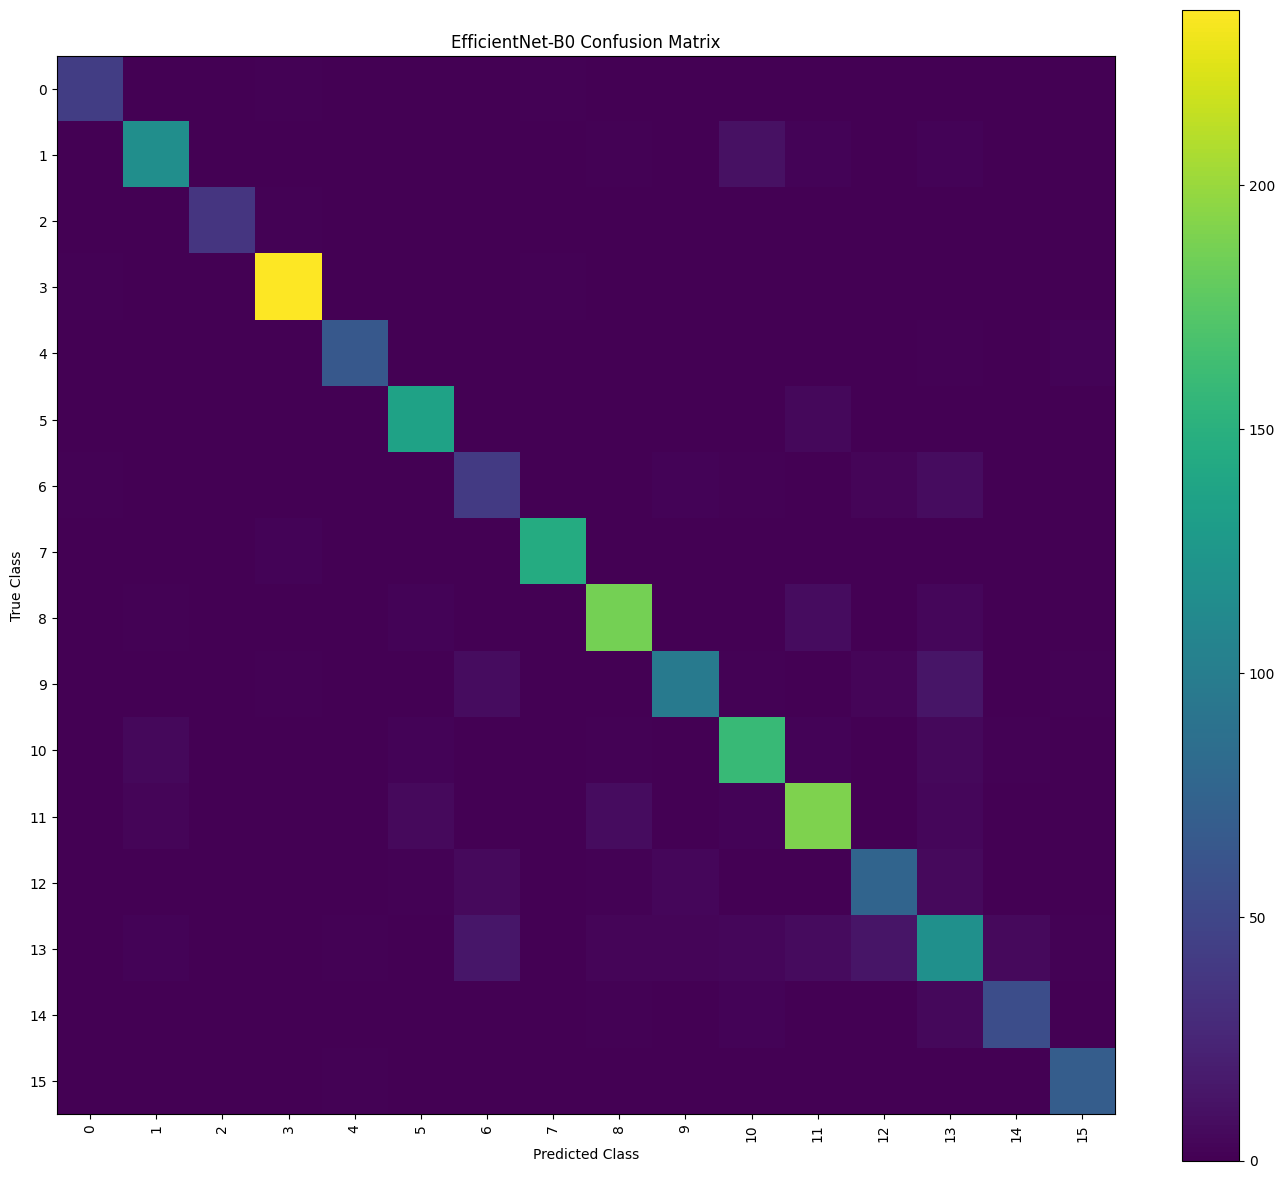

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

cm = confusion.copy()

# Remove accidental index column
if "Unnamed: 0" in cm.columns:
    cm = cm.drop(columns=["Unnamed: 0"])

# If the first column contains class names
if not pd.api.types.is_numeric_dtype(cm.iloc[:, 0]):
    class_names = cm.iloc[:, 0].astype(str).tolist()
    cm_values = cm.iloc[:, 1:].values
else:
    class_names = [str(i) for i in range(cm.shape[1])]
    cm_values = cm.values

plt.figure(figsize=(14, 12))
plt.imshow(cm_values, interpolation="nearest")
plt.title("EfficientNet-B0 Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=90
)
plt.yticks(
    range(len(class_names)),
    class_names
)
plt.colorbar()
plt.tight_layout()
plt.show()

In [ ]:
from pathlib import Path
import pandas as pd
import json

PROJECT = Path("/content/smart-waste-segregation-ai")

OUTPUT = PROJECT / "training_outputs" / "efficientnet_b0_cached"
ANALYSIS = PROJECT / "analysis"

ANALYSIS.mkdir(exist_ok=True)

# ---------------------------------------------------------
# Load results
# ---------------------------------------------------------

with open(OUTPUT / "test_results.json", "r") as f:
    results = json.load(f)

report = pd.read_csv(OUTPUT / "classification_report.csv")

# Remove accidental index column
if "Unnamed: 0" in report.columns:
    report = report.drop(columns=["Unnamed: 0"])

# Your known class names
class_names = [
    "Battery",
    "Cardboard",
    "Electronic Component",
    "Electronic Device",
    "Food Organics",
    "Glass",
    "Hazardous Waste",
    "Large Electronic Appliance",
    "Metal",
    "Organic Stream",
    "Paper",
    "Plastic",
    "Recyclable Stream",
    "Residual",
    "Textile",
    "Vegetation"
]

# ---------------------------------------------------------
# Extract class metrics
# ---------------------------------------------------------

class_report = report.iloc[:16].copy()

class_report.insert(
    0,
    "class_name",
    class_names
)

# ---------------------------------------------------------
# Generate final analysis
# ---------------------------------------------------------

lines = []

lines.append("=" * 75)
lines.append("SMART WASTE SEGREGATION AI")
lines.append("FINAL MODEL ANALYSIS")
lines.append("=" * 75)

lines.append("")
lines.append("MODEL")
lines.append("-" * 75)
lines.append("Architecture: EfficientNet-B0")
lines.append("Parameters: approximately 4.03 million")
lines.append("Input size: 224 x 224")
lines.append("Classes: 16")

lines.append("")
lines.append("DATASET")
lines.append("-" * 75)
lines.append("Total images: 13,196")
lines.append("Training images: 9,237")
lines.append("Validation images: 1,980")
lines.append("Test images: 1,979")

lines.append("")
lines.append("FINAL PERFORMANCE")
lines.append("-" * 75)

lines.append(
    f"Test Accuracy : {results['test_accuracy'] * 100:.2f}%"
)

lines.append(
    f"Macro Precision: {results['macro_precision'] * 100:.2f}%"
)

lines.append(
    f"Macro Recall   : {results['macro_recall'] * 100:.2f}%"
)

lines.append(
    f"Macro F1       : {results['macro_f1']:.4f}"
)

lines.append(
    f"Best Epoch     : {results['best_epoch']}"
)

lines.append(
    f"Validation Acc : {results['best_validation_accuracy'] * 100:.2f}%"
)

lines.append("")
lines.append("CLASS-WISE PERFORMANCE")
lines.append("-" * 75)

for _, row in class_report.iterrows():

    lines.append(
        f"{row['class_name']:<30} "
        f"Precision={row['precision']:.3f}  "
        f"Recall={row['recall']:.3f}  "
        f"F1={row['f1-score']:.3f}  "
        f"Support={int(row['support'])}"
    )

lines.append("")
lines.append("WHY THIS RESULT?")
lines.append("-" * 75)

lines.append(
    "1. EfficientNet-B0 substantially outperformed the ResNet18 baseline."
)

lines.append(
    "2. The strongest performance occurs on visually distinctive waste categories."
)

lines.append(
    "3. Errors are concentrated in visually or semantically overlapping categories."
)

lines.append(
    "4. Hazardous Waste and Residual are the two weakest classes."
)

lines.append(
    "5. Residual is frequently confused with Hazardous Waste and Recyclable Stream."
)

lines.append(
    "6. Organic Stream is mainly confused with Textile and Hazardous Waste."
)

lines.append(
    "7. Cardboard and Paper show expected visual similarity."
)

lines.append(
    "8. Plastic is occasionally confused with Metal and Glass."
)

lines.append(
    "9. Therefore, remaining errors are concentrated around ambiguous waste categories rather than being uniformly distributed."
)

lines.append("")
lines.append("MODEL SELECTION")
lines.append("-" * 75)

lines.append(
    "ResNet18 Test Accuracy : 75.34%"
)

lines.append(
    "ResNet18 Macro F1      : 0.7354"
)

lines.append(
    "EfficientNet-B0 Test Accuracy : 89.49%"
)

lines.append(
    "EfficientNet-B0 Macro F1      : 0.8920"
)

lines.append("")
lines.append(
    "EfficientNet-B0 is selected as the final candidate model."
)

lines.append("")
lines.append("=" * 75)

analysis_file = ANALYSIS / "final_model_analysis.txt"

with open(analysis_file, "w", encoding="utf-8") as f:
    f.write("\n".join(lines))

print("\n".join(lines))

print("\nSaved:")
print(analysis_file)

SMART WASTE SEGREGATION AI
FINAL MODEL ANALYSIS

MODEL
---------------------------------------------------------------------------
Architecture: EfficientNet-B0
Parameters: approximately 4.03 million
Input size: 224 x 224
Classes: 16

DATASET
---------------------------------------------------------------------------
Total images: 13,196
Training images: 9,237
Validation images: 1,980
Test images: 1,979

FINAL PERFORMANCE
---------------------------------------------------------------------------
Test Accuracy : 89.49%
Macro Precision: 89.23%
Macro Recall   : 89.36%
Macro F1       : 0.8920
Best Epoch     : 10
Validation Acc : 89.75%

CLASS-WISE PERFORMANCE
---------------------------------------------------------------------------
Battery                        Precision=0.956  Recall=0.956  F1=0.956  Support=45
Cardboard                      Precision=0.914  Recall=0.880  F1=0.897  Support=133
Electronic Component           Precision=1.000  Recall=0.973  F1=0.986  Support=37
Electroni

In [ ]:
!ls -lh training_outputs/efficientnet_b0_cached/

total 16M
-rw-r--r-- 1 root root  16M Sep  5 16:51 best_model.pth
-rw-r--r-- 1 root root 1.4K Sep  5 16:53 classification_report.csv
-rw-r--r-- 1 root root  943 Sep  5 16:53 confusion_matrix.csv
-rw-r--r-- 1 root root  365 Sep  5 16:53 test_results.json
-rw-r--r-- 1 root root 1.3K Sep  5 16:52 training_history.csv
-rw-r--r-- 1 root root  588 Sep  5 16:53 training_metadata.json


In [ ]:
from pathlib import Path

images = list(Path("data/raw").rglob("*.jpg"))

print("Images found:", len(images))

for image in images[:5]:
    print(image)

Images found: 12678
data/raw/realwaste/Plastic/Plastic_821.jpg
data/raw/realwaste/Plastic/Plastic_155.jpg
data/raw/realwaste/Plastic/Plastic_617.jpg
data/raw/realwaste/Plastic/Plastic_638.jpg
data/raw/realwaste/Plastic/Plastic_531.jpg


In [ ]:
!python ml/interface.py "data/raw/realwaste/Plastic/Plastic_821.jpg"


ERROR
------------------------------------------------------------
Class names file not found:
/content/smart-waste-segregation-ai/training_outputs/efficientnet_b0_cached/class_names.json



In [54]:
import json
from pathlib import Path

OUTPUT_DIR = Path(
    "/content/smart-waste-segregation-ai/"
    "training_outputs/efficientnet_b0_cached"
)

class_names = [
    "Battery",
    "Cardboard",
    "Electronic Component",
    "Electronic Device",
    "Food Organics",
    "Glass",
    "Hazardous Waste",
    "Large Electronic Appliance",
    "Metal",
    "Organic Stream",
    "Paper",
    "Plastic",
    "Recyclable Stream",
    "Residual",
    "Textile",
    "Vegetation",
]

class_to_idx = {
    name: i for i, name in enumerate(class_names)
}

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

with open(OUTPUT_DIR / "class_names.json", "w") as f:
    json.dump(class_names, f, indent=2)

with open(OUTPUT_DIR / "class_to_idx.json", "w") as f:
    json.dump(class_to_idx, f, indent=2)

print("DONE")
print("Created:", OUTPUT_DIR / "class_names.json")
print("Created:", OUTPUT_DIR / "class_to_idx.json")

DONE
Created: /content/smart-waste-segregation-ai/training_outputs/efficientnet_b0_cached/class_names.json
Created: /content/smart-waste-segregation-ai/training_outputs/efficientnet_b0_cached/class_to_idx.json


In [55]:
from pathlib import Path

output_dir = Path(
    "/content/smart-waste-segregation-ai/"
    "training_outputs/efficientnet_b0_cached"
)

for file in sorted(output_dir.iterdir()):
    print(f"{file.name:30} {file.stat().st_size / 1024:.1f} KB")

best_model.pth                 16028.0 KB
class_names.json               0.3 KB
class_to_idx.json              0.3 KB
classification_report.csv      1.4 KB
confusion_matrix.csv           0.9 KB
test_results.json              0.4 KB
training_history.csv           1.3 KB
training_metadata.json         0.6 KB


In [56]:
!python ml/interface.py "data/raw/realwaste/Plastic/Plastic_821.jpg"


SMART WASTE SEGREGATION AI
Image      : data/raw/realwaste/Plastic/Plastic_821.jpg
Model      : efficientnet_b0
Device     : cuda

PREDICTION
------------------------------------------------------------
Class      : Plastic
Confidence : 96.90%

TOP PREDICTIONS
------------------------------------------------------------
1. Plastic                         96.90%
2. Metal                            0.47%
3. Recyclable Stream                0.36%



In [57]:
!python ml/explain.py "data/raw/realwaste/Plastic/Plastic_821.jpg"


WHY THIS RESULT
Prediction : Plastic
Confidence : 96.90%
Explanation:
/content/smart-waste-segregation-ai/training_outputs/explanations/explanation_Plastic_821.jpg


In [ ]:
import shutil
import os
from google.colab import files

PROJECT = "/content/smart-waste-segregation-ai"

# Create final submission package
zip_base = "/content/smart_waste_ai_final"

shutil.make_archive(
    zip_base,
    "zip",
    PROJECT
)

zip_path = zip_base + ".zip"

size = os.path.getsize(zip_path) / (1024 ** 2)

print(f"Created: {zip_path}")
print(f"Size: {size:.2f} MB")

files.download(zip_path)